### 导入必要的库

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 设置随机种子以保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cpu


### 定义神经网络结构

In [2]:
class NeuralNet(nn.Module):
    """
    全连接神经网络
    """

    def __init__(self, input_dimension, output_dimension, n_hidden_layers, neurons):
        super(NeuralNet, self).__init__()

        # 输入层
        self.input_layer = nn.Linear(input_dimension, neurons)

        # 隐藏层
        self.hidden_layers = nn.ModuleList([
            nn.Linear(neurons, neurons) for _ in range(n_hidden_layers)
        ])

        # 输出层
        self.output_layer = nn.Linear(neurons, output_dimension)

        # 激活函数
        self.activation = nn.Tanh()

    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.activation(layer(x))
        return self.output_layer(x)

### 定义 PINN 反问题类

In [8]:
class PINNInverse:
    """
    PINN 反问题求解器：同时求解 u(t,x) 和 k(x)
    """

    def __init__(self):
        # 网络1：近似解 u(t, x)
        self.approximate_solution = NeuralNet(
            input_dimension=2,    # (t, x)
            output_dimension=1,   # u
            n_hidden_layers=4,
            neurons=50
        ).to(device)

        # 网络2：近似未知系数 k(x)
        self.approximate_coefficient = NeuralNet(
            input_dimension=1,    # 只有 x
            output_dimension=1,   # k
            n_hidden_layers=4,
            neurons=50
        ).to(device)

        # 合并两个网络的参数
        self.params = list(self.approximate_solution.parameters()) + \
            list(self.approximate_coefficient.parameters())

    def exact_solution(self, t, x):
        """解析解：u(t, x) = -exp(-π²t) * sin(πx)"""
        return -torch.exp(-np.pi**2 * t) * torch.sin(np.pi * x)

    def exact_k(self, x):
        """真实的热导率：k(x) = sin(πx) + 1.1"""
        return torch.sin(np.pi * x) + 1.1

    def source_term(self, t, x, u, k):
        """源项：s = -π² * u * (1 - k(x))"""
        return -np.pi**2 * u * (1 - k)

    def compute_pde_residual(self, input_int):
        """
        计算 PDE 残差：r = u_t - k(x)·u_xx - s(t,x)
        """
        input_int.requires_grad_(True)

        # u 的预测
        u = self.approximate_solution(input_int)

        # k 的预测：k = k(x)，只取空间坐标
        k = self.approximate_coefficient(input_int[:, 1:2])

        # 计算一阶导数 u_t
        grad_u = torch.autograd.grad(
            outputs=u,
            inputs=input_int,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        u_t = grad_u[:, 0:1]  # 对 t 的导数
        u_x = grad_u[:, 1:2]  # 对 x 的导数

        # 计算二阶导数 u_xx
        grad_u_x = torch.autograd.grad(
            outputs=u_x,
            inputs=input_int,
            grad_outputs=torch.ones_like(u_x),
            create_graph=True
        )[0]

        u_xx = grad_u_x[:, 1:2]  # 对 x 的二阶导数

        # 源项
        s = self.source_term(input_int[:, 0:1], input_int[:, 1:2], u, k)

        # PDE 残差
        residual = u_t - k * u_xx - s

        return residual

    def compute_boundary_loss(self, input_sb, u_sb):
        """计算空间边界损失"""
        u_pred_sb = self.approximate_solution(input_sb)
        return torch.mean((u_pred_sb - u_sb) ** 2)

    def compute_initial_loss(self, input_tb, u_tb):
        """计算初始条件损失"""
        u_pred_tb = self.approximate_solution(input_tb)
        return torch.mean((u_pred_tb - u_tb) ** 2)

    def compute_data_loss(self, input_meas, u_meas):
        """计算测量数据损失"""
        u_pred_meas = self.approximate_solution(input_meas)
        return torch.mean((u_pred_meas - u_meas) ** 2)

    def compute_total_loss(self, input_int, input_sb, u_sb, input_tb, u_tb,
                           input_meas, u_meas, lambda_sb=10.0, lambda_tb=10.0,
                           lambda_int=1.0, lambda_data=10.0):
        """
        计算总损失
        L = λ_sb·L_sb + λ_tb·L_tb + λ_int·L_int + λ_data·L_data
        """
        # PDE 残差损失
        residual = self.compute_pde_residual(input_int)
        loss_pde = torch.mean(residual ** 2)

        # 空间边界损失
        loss_sb = self.compute_boundary_loss(input_sb, u_sb)

        # 初始条件损失
        loss_tb = self.compute_initial_loss(input_tb, u_tb)

        # 测量数据损失
        loss_data = self.compute_data_loss(input_meas, u_meas)

        # 总损失
        total_loss = lambda_sb * loss_sb + lambda_tb * loss_tb + \
            lambda_int * loss_pde + lambda_data * loss_data

        return total_loss, loss_sb, loss_tb, loss_pde, loss_data

    def evaluate_losses(self, input_int, input_sb, u_sb, input_tb, u_tb,
                        input_meas, u_meas):
        """
        评估模式：计算各项损失但不构建计算图
        """
        with torch.no_grad():
            # 边界、初始条件和测量数据损失（不需要梯度）
            loss_sb = self.compute_boundary_loss(input_sb, u_sb)
            loss_tb = self.compute_initial_loss(input_tb, u_tb)
            loss_data = self.compute_data_loss(input_meas, u_meas)

        # PDE 残差损失需要计算梯度，但我们可以用简化版本
        # 或者直接用标准版本（在评估时梯度会自动释放）
        residual = self.compute_pde_residual(input_int)
        with torch.no_grad():
            loss_pde = torch.mean(residual ** 2)

        total_loss = 10.0 * loss_sb + 10.0 * loss_tb + loss_pde + 10.0 * loss_data

        return total_loss, loss_sb, loss_tb, loss_pde, loss_data

### 生成训练数据

In [4]:
def generate_training_data(n_int=128, n_sb=64, n_tb=64, n_meas=50):
    """
    生成训练数据
    - n_int: 内部配点数量
    - n_sb: 空间边界点数量
    - n_tb: 时间边界点数量（初始条件）
    - n_meas: 测量数据点数量
    """
    # 定义域：t ∈ [0, 0.1], x ∈ [-1, 1]

    # 1. 内部配点（用于 PDE 残差）
    t_int = torch.rand(n_int, 1) * 0.1  # t ∈ [0, 0.1]
    x_int = torch.rand(n_int, 1) * 2 - 1  # x ∈ [-1, 1]
    input_int = torch.cat([t_int, x_int], dim=1).to(device)

    # 2. 空间边界点（x = -1 和 x = 1，t 随机）
    t_sb = torch.rand(n_sb, 1) * 0.1
    x_sb_left = torch.full((n_sb, 1), -1.0)
    x_sb_right = torch.full((n_sb, 1), 1.0)

    input_sb_left = torch.cat([t_sb, x_sb_left], dim=1).to(device)
    input_sb_right = torch.cat([t_sb, x_sb_right], dim=1).to(device)
    input_sb = torch.cat([input_sb_left, input_sb_right], dim=0)

    # 边界条件：u(-1) = u(1) = 0
    u_sb = torch.zeros(input_sb.shape[0], 1).to(device)

    # 3. 初始条件点（t = 0，x 随机）
    t_tb = torch.zeros(n_tb, 1)
    x_tb = torch.rand(n_tb, 1) * 2 - 1
    input_tb = torch.cat([t_tb, x_tb], dim=1).to(device)

    # 初始条件：u(0, x) = -sin(πx)
    u_tb = -torch.sin(np.pi * x_tb).to(device)

    # 4. 测量数据点（模拟传感器读数）
    t_meas = torch.rand(n_meas, 1) * 0.1
    x_meas = torch.rand(n_meas, 1) * 2 - 1
    input_meas = torch.cat([t_meas, x_meas], dim=1).to(device)

    # 解析解 + 噪声（模拟真实测量）
    u_meas_exact = -torch.exp(-np.pi**2 * t_meas) * torch.sin(np.pi * x_meas)
    noise = 0.01 * torch.randn_like(u_meas_exact)  # 1% 噪声
    u_meas = (u_meas_exact + noise).to(device)

    return input_int, input_sb, u_sb, input_tb, u_tb, input_meas, u_meas


# 生成数据
input_int, input_sb, u_sb, input_tb, u_tb, input_meas, u_meas = generate_training_data(
    n_int=128, n_sb=64, n_tb=64, n_meas=50
)

print(f"内部配点: {input_int.shape}")
print(f"空间边界点: {input_sb.shape}")
print(f"初始条件点: {input_tb.shape}")
print(f"测量数据点: {input_meas.shape}")

内部配点: torch.Size([128, 2])
空间边界点: torch.Size([128, 2])
初始条件点: torch.Size([64, 2])
测量数据点: torch.Size([50, 2])


### 训练模型（Adam 预训练）

In [25]:
# 创建 PINN 模型
pinn = PINNInverse()

# Adam 优化器（预训练）
optimizer_adam = optim.Adam(pinn.params, lr=1e-3)

# 训练参数
n_epochs_adam = 5000
print_every = 500

# 记录损失历史
loss_history_adam = []

print("=" * 60)
print("阶段 1：Adam 预训练")
print("=" * 60)

for epoch in range(n_epochs_adam):
    optimizer_adam.zero_grad()

    # 计算损失
    total_loss, loss_sb, loss_tb, loss_pde, loss_data = pinn.compute_total_loss(
        input_int, input_sb, u_sb, input_tb, u_tb, input_meas, u_meas
    )

    # 反向传播
    total_loss.backward()
    optimizer_adam.step()

    # 记录损失
    loss_history_adam.append(total_loss.item())

    # 打印进度
    if (epoch + 1) % print_every == 0 or epoch == 0:
        print(f"Epoch {epoch+1:5d} | Total: {total_loss.item():.2e} | "
              f"PDE: {loss_pde.item():.2e} | SB: {loss_sb.item():.2e} | "
              f"TB: {loss_tb.item():.2e} | Data: {loss_data.item():.2e}")

print("\nAdam 预训练完成！")

阶段 1：Adam 预训练
Epoch     1 | Total: 7.24e+00 | PDE: 1.44e-02 | SB: 4.76e-04 | TB: 5.03e-01 | Data: 2.19e-01
Epoch   500 | Total: 1.04e+00 | PDE: 2.43e-01 | SB: 3.17e-02 | TB: 3.78e-02 | Data: 9.85e-03
Epoch  1000 | Total: 3.40e-01 | PDE: 4.99e-02 | SB: 1.64e-02 | TB: 1.03e-02 | Data: 2.36e-03
Epoch  1500 | Total: 2.79e-01 | PDE: 3.96e-02 | SB: 1.45e-02 | TB: 7.73e-03 | Data: 1.71e-03
Epoch  2000 | Total: 2.37e-01 | PDE: 3.28e-02 | SB: 1.27e-02 | TB: 6.34e-03 | Data: 1.46e-03
Epoch  2500 | Total: 1.82e-01 | PDE: 3.44e-02 | SB: 9.28e-03 | TB: 4.35e-03 | Data: 1.08e-03
Epoch  3000 | Total: 2.05e-01 | PDE: 7.16e-02 | SB: 5.74e-03 | TB: 6.35e-03 | Data: 1.28e-03
Epoch  3500 | Total: 5.81e-02 | PDE: 2.36e-02 | SB: 2.47e-03 | TB: 7.31e-04 | Data: 2.44e-04
Epoch  4000 | Total: 3.59e-02 | PDE: 1.70e-02 | SB: 1.10e-03 | TB: 4.78e-04 | Data: 3.14e-04
Epoch  4500 | Total: 1.90e-02 | PDE: 6.29e-03 | SB: 7.31e-04 | TB: 3.65e-04 | Data: 1.72e-04
Epoch  5000 | Total: 1.65e-02 | PDE: 5.21e-03 | SB: 7.00

### 训练模型（LBFGS 精调）

In [27]:
# LBFGS 优化器（精调）
optimizer_lbfgs = optim.LBFGS(
    pinn.params,
    lr=0.5,
    max_iter=50000,
    history_size=100,
    line_search_fn='strong_wolfe'
)

print("=" * 60)
print("阶段 2：LBFGS 精调")
print("=" * 60)

# 定义闭包函数（LBFGS 需要）
loss_history_lbfgs = []
def closure():
    optimizer_lbfgs.zero_grad()
    total_loss, loss_sb, loss_tb, loss_pde, loss_data = pinn.compute_total_loss(
        input_int, input_sb, u_sb, input_tb, u_tb, input_meas, u_meas
    )
    total_loss.backward()
    loss_history_lbfgs.append(total_loss.item())
    return total_loss

# 执行 LBFGS 优化
optimizer_lbfgs.step(closure)

# 计算最终损失（不使用 torch.no_grad()，因为 compute_pde_residual 需要计算梯度）
final_loss, loss_sb, loss_tb, loss_pde, loss_data = pinn.compute_total_loss(
    input_int, input_sb, u_sb, input_tb, u_tb, input_meas, u_meas
)

print(f"\n最终损失 | Total: {final_loss.item():.2e} | "
      f"PDE: {loss_pde.item():.2e} | SB: {loss_sb.item():.2e} | "
      f"TB: {loss_tb.item():.2e} | Data: {loss_data.item():.2e}")

print("\nLBFGS 精调完成！")

阶段 2：LBFGS 精调

最终损失 | Total: 1.20e-03 | PDE: 1.63e-04 | SB: 3.68e-07 | TB: 5.61e-06 | Data: 9.79e-05

LBFGS 精调完成！


### 可视化训练损失

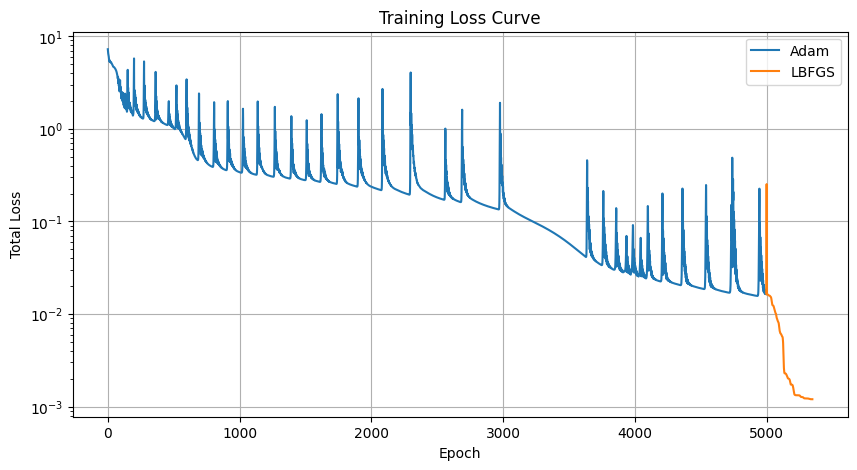

In [33]:
# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(loss_history_adam)), loss_history_adam, label='Adam')
plt.plot(np.arange(len(loss_history_lbfgs))+len(loss_history_adam), loss_history_lbfgs, label='LBFGS')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Training Loss Curve')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()

### 评估 $k(x)$ 辨识效果

k(x) 辨识平均相对误差: 100.91%


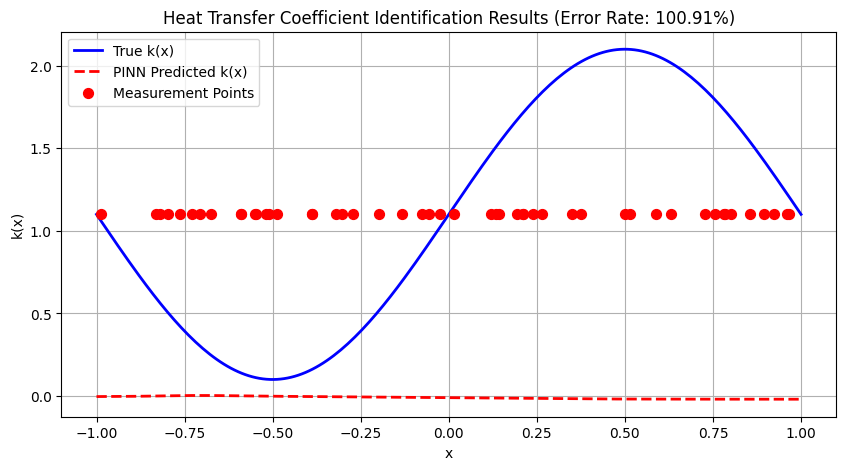

In [36]:
# 生成测试点
x_test = torch.linspace(-1, 1, 200).reshape(-1, 1).to(device)

# 预测 k(x)
with torch.no_grad():
    k_pred = pinn.approximate_coefficient(x_test).cpu().numpy()
    k_true = pinn.exact_k(x_test).cpu().numpy()

# 计算相对误差
rel_error = np.abs(k_pred - k_true).mean() / np.abs(k_true).mean() * 100

print(f"k(x) 辨识平均相对误差: {rel_error:.2f}%")

# 可视化 k(x) 辨识结果
plt.figure(figsize=(10, 5))
plt.plot(x_test.cpu().numpy(), k_true, 'b-', linewidth=2, label='True k(x)')
plt.plot(x_test.cpu().numpy(), k_pred, 'r--',
         linewidth=2, label='PINN Predicted k(x)')

# 标记测量点位置
x_meas_unique = input_meas[:, 1].unique().cpu().numpy()
plt.scatter(x_meas_unique, [1.1] * len(x_meas_unique),
            c='red', s=50, marker='o', label='Measurement Points', zorder=5)

plt.xlabel('x')
plt.ylabel('k(x)')
plt.title(f'Heat Transfer Coefficient Identification Results (Error Rate: {rel_error:.2f}%)')
plt.legend()
plt.grid(True)
plt.show()

### 可视化 $u(t, x)$ 预测结果

u(t, x) 预测平均相对误差: 0.18%


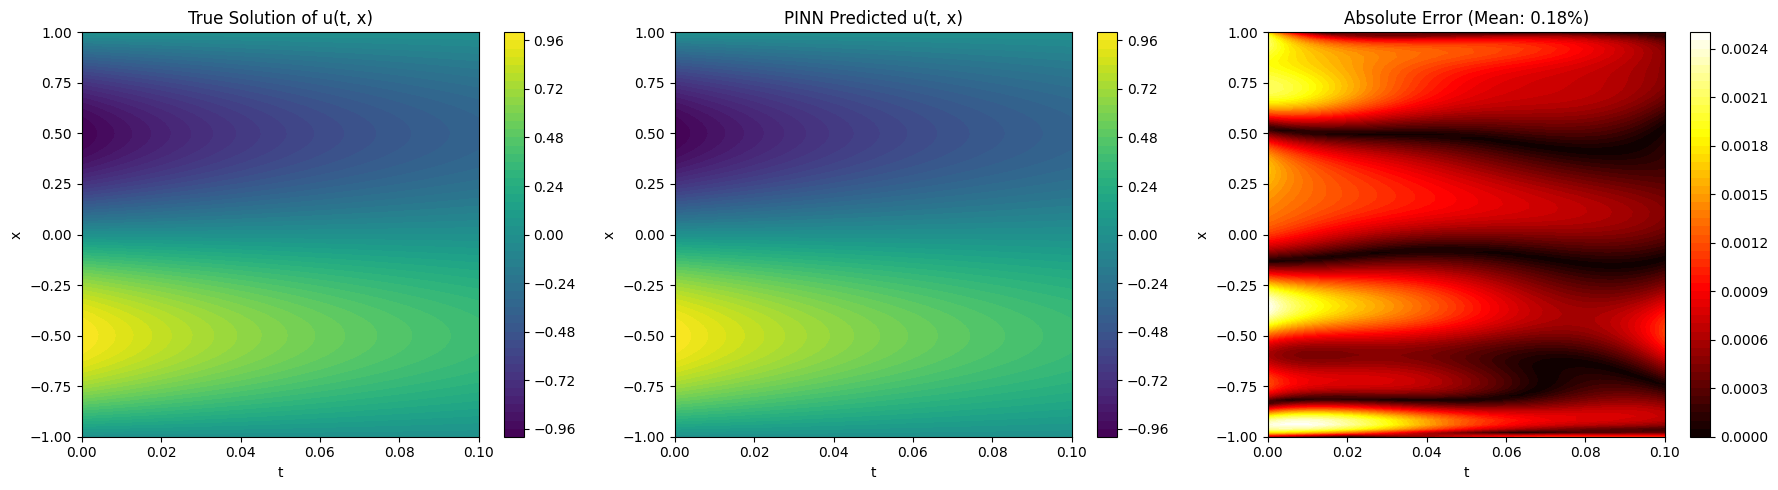

In [19]:
# 生成网格点
t_plot = torch.linspace(0, 0.1, 50)
x_plot = torch.linspace(-1, 1, 100)
T, X = torch.meshgrid(t_plot, x_plot, indexing='ij')

# 准备输入
input_plot = torch.cat([T.reshape(-1, 1), X.reshape(-1, 1)], dim=1).to(device)

# PINN 预测
with torch.no_grad():
    u_pred = pinn.approximate_solution(
        input_plot).cpu().numpy().reshape(T.shape)
    u_exact = pinn.exact_solution(T.to(device), X.to(device)).cpu().numpy()

# 计算预测误差
error = np.abs(u_pred - u_exact)
rel_error_u = error.mean() / np.abs(u_exact).mean() * 100

print(f"u(t, x) 预测平均相对误差: {rel_error_u:.2f}%")

# 绘制对比图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 真实解
im1 = axes[0].contourf(T.numpy(), X.numpy(), u_exact,
                       levels=50, cmap='viridis')
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
axes[0].set_title('True Solution of u(t, x)')
plt.colorbar(im1, ax=axes[0])

# PINN 预测
im2 = axes[1].contourf(T.numpy(), X.numpy(), u_pred, levels=50, cmap='viridis')
axes[1].set_xlabel('t')
axes[1].set_ylabel('x')
axes[1].set_title('PINN Predicted u(t, x)')
plt.colorbar(im2, ax=axes[1])

# 误差分布
im3 = axes[2].contourf(T.numpy(), X.numpy(), error, levels=50, cmap='hot')
axes[2].set_xlabel('t')
axes[2].set_ylabel('x')
axes[2].set_title(f'Absolute Error (Mean: {rel_error_u:.2f}%)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()